# Limpieza del dataset de calidad de agua - HydroForest

Este notebook prepara el dataset *A Comprehensive Surface Water Quality
Monitoring Dataset (1940-2023)* para el entrenamiento del modelo Random Forest del proyecto HydroForest.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (8, 4)

## 0. Configuración

In [5]:
INPUT_PATH = "water_quality.csv"        
OUTPUT_PATH = "water_quality_clean.csv"     

TARGET_COL = "CCME_WQI"

LEAKAGE_COL = "CCME_Values"

VALID_RANGES = {
    "pH_ph_units": (0, 14),
    "Dissolved_Oxygen_mgl": (0, 20),
    "Biochemical_Oxygen_Demand_mgl": (0, None),
    "Ammonia_mgl": (0, None),
    "Nitrate_mgl": (0, None),
    "Orthophosphate_mgl": (0, None),
    "Nitrogen_mgl": (0, None),
    "Temperature_cel": (-5, 45),
}

GROUP_COL_FOR_IMPUTATION = "Country"  

## 1. Carga y diagnóstico inicial

Cargamos el CSV y revisamos su tamaño, tipos de dato y el porcentaje de valores nulos por columna antes de tocar nada.

In [6]:
df = pd.read_csv(INPUT_PATH, low_memory=False)
filas_inicial, columnas_inicial = df.shape
print(f"Filas: {filas_inicial:,}")
print(f"Columnas: {columnas_inicial}")
df.head()

Filas: 2,827,977
Columnas: 14


,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,Canada,SE649035-145565,River,12-01-1974,0.059248,1.30,8.1500,0.011917,8.07500,9.885,0.343917,11.73155,100.0,Excellent
1,Canada,SE649035-145565,River,12-01-1975,0.039821,1.38,7.8000,0.009417,7.73333,10.150,0.449083,11.82009,100.0,Excellent
2,Canada,SE649035-145565,River,12-01-1976,0.031341,2.23,7.8000,0.011000,7.46667,10.235,0.220750,14.87472,100.0,Excellent
3,Canada,SE649035-145565,River,12-01-1977,0.020501,1.61,8.1500,0.012333,7.78333,11.116,0.572250,15.89293,100.0,Excellent
4,Canada,SE649035-145565,River,12-01-1978,0.020023,1.64,4.3708,0.006182,7.10000,7.068,0.371091,15.22888,100.0,Excellent


In [7]:
df.dtypes

Country                                 str
Area                                    str
Waterbody Type                          str
Date                                    str
Ammonia (mg/l)                      float64
Biochemical Oxygen Demand (mg/l)    float64
Dissolved Oxygen (mg/l)             float64
Orthophosphate (mg/l)               float64
pH (ph units)                       float64
Temperature (cel)                   float64
Nitrogen (mg/l)                     float64
Nitrate (mg/l)                      float64
CCME_Values                         float64
CCME_WQI                                str
dtype: object

In [8]:
missing_antes = (df.isna().mean() * 100).sort_values(ascending=False)
missing_antes[missing_antes > 0].round(2)

Series([], dtype: float64)

In [9]:
top_missing = missing_antes[missing_antes > 0].head(15)
if len(top_missing):
    top_missing.plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.xlabel("% de valores nulos")
    plt.title("Valores nulos por columna (antes de limpiar)")
    plt.tight_layout()
    plt.show()
else:
    print("No hay valores nulos en el dataset original.")

No hay valores nulos en el dataset original.


## 2. Normalización de nombres de columnas

Quitamos espacios y caracteres raros de los encabezados para trabajar más cómodo.

In [10]:
df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)
df.columns.tolist()

['Country',
 'Area',
 'Waterbody_Type',
 'Date',
 'Ammonia_mgl',
 'Biochemical_Oxygen_Demand_mgl',
 'Dissolved_Oxygen_mgl',
 'Orthophosphate_mgl',
 'pH_ph_units',
 'Temperature_cel',
 'Nitrogen_mgl',
 'Nitrate_mgl',
 'CCME_Values',
 'CCME_WQI']

## 3. Eliminación de duplicados

Registros idénticos en todas sus columnas no aportan información nueva al modelo.

In [11]:
filas_antes = len(df)
df = df.drop_duplicates()
duplicados_eliminados = filas_antes - len(df)
print(f"Duplicados eliminados: {duplicados_eliminados:,}")
print(f"Filas restantes: {len(df):,}")

Duplicados eliminados: 9,971
Filas restantes: 2,818,006


## 4. Eliminación de filas sin variable objetivo

Sin la clasificación de calidad de agua no podemos usar esa fila para entrenar el modelo
de clasificación, así que se descartan.

In [12]:
if TARGET_COL in df.columns:
    filas_antes = len(df)
    df = df.dropna(subset=[TARGET_COL])
    print(f"Filas sin variable objetivo eliminadas: {filas_antes - len(df):,}")
    print(f"Filas restantes: {len(df):,}")
else:
    print(f"AVISO: no se encontró la columna '{TARGET_COL}'.")
    print("Columnas disponibles:", df.columns.tolist())

Filas sin variable objetivo eliminadas: 0
Filas restantes: 2,818,006


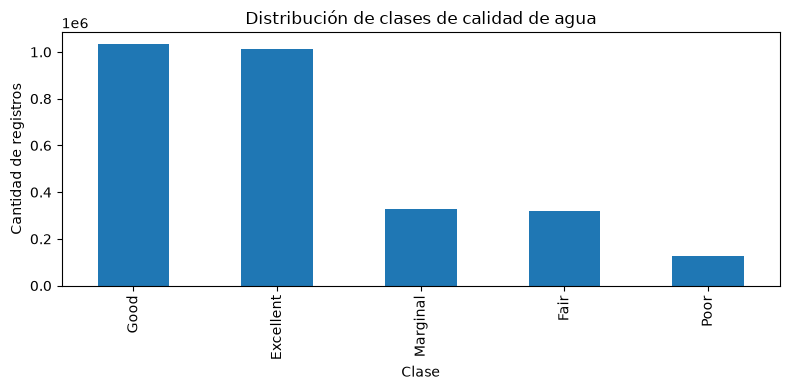

In [13]:
if TARGET_COL in df.columns:
    df[TARGET_COL].value_counts().plot(kind="bar")
    plt.title("Distribución de clases de calidad de agua")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de registros")
    plt.tight_layout()
    plt.show()

## 5. Validación de rangos físicamente válidos

Valores fuera de rango físicamente posible, por ejemplo, pH negativo o concentraciones negativas se marcan como nulos para luego imputarlos, en vez de dejarlos pasar como si fueran válidos.

In [14]:
for col, (lo, hi) in VALID_RANGES.items():
    if col not in df.columns:
        continue
    mask = pd.Series(False, index=df.index)
    if lo is not None:
        mask |= df[col] < lo
    if hi is not None:
        mask |= df[col] > hi
    n_invalid = int(mask.sum())
    if n_invalid:
        print(f"'{col}': {n_invalid:,} valores fuera de rango [{lo}, {hi}] marcados como NaN")
        df.loc[mask, col] = np.nan

'pH_ph_units': 505 valores fuera de rango [0, 14] marcados como NaN
'Biochemical_Oxygen_Demand_mgl': 2 valores fuera de rango [0, None] marcados como NaN
'Ammonia_mgl': 2 valores fuera de rango [0, None] marcados como NaN
'Orthophosphate_mgl': 10 valores fuera de rango [0, None] marcados como NaN
'Temperature_cel': 6,819 valores fuera de rango [-5, 45] marcados como NaN


## 6. Columnas con exceso de valores nulos

Si una columna tiene más de 50% de nulos, aporta poco y se descarta en vez de imputarla a ciegas.

In [15]:
UMBRAL_NULOS = 0.5
ratios = df.isna().mean()
columnas_a_eliminar = ratios[ratios > UMBRAL_NULOS].index.tolist()
if columnas_a_eliminar:
    print(f"Columnas descartadas por más de {UMBRAL_NULOS*100:.0f}% de nulos: {columnas_a_eliminar}")
    df = df.drop(columns=columnas_a_eliminar)
else:
    print("Ninguna columna supera el umbral de nulos.")

Ninguna columna supera el umbral de nulos.


## 7. Imputación de valores numéricos

Para las columnas numéricas restantes con nulos, se imputa con la mediana, agrupada por país o región cuando es posible.

In [16]:
columnas_numericas = df.select_dtypes(include=[np.number]).columns
imputadas = []
for col in columnas_numericas:
    if df[col].isna().sum() == 0:
        continue
    imputadas.append(col)
    if GROUP_COL_FOR_IMPUTATION in df.columns:
        df[col] = df.groupby(GROUP_COL_FOR_IMPUTATION)[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

print(f"Columnas imputadas: {imputadas}")

Columnas imputadas: ['Ammonia_mgl', 'Biochemical_Oxygen_Demand_mgl', 'Orthophosphate_mgl', 'pH_ph_units', 'Temperature_cel']


## 8. Conversión de fechas

Convertimos la fecha a formato datetime para poder
usarla en análisis o filtros posteriores.

In [17]:
for col in ["Date", "SampleDate", "Sample_Date", "sample_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)
        print(f"Columna de fecha detectada y convertida: '{col}'")
        break
else:
    print("No se detectó una columna de fecha con los nombres esperados.")

Columna de fecha detectada y convertida: 'Date'


## 9. Resumen final y guardado


In [18]:
missing_despues = (df.isna().mean() * 100).sort_values(ascending=False)

resumen = pd.DataFrame({
    "Filas": [filas_inicial, len(df)],
    "Columnas": [columnas_inicial, df.shape[1]],
    "% nulos promedio": [missing_antes.mean().round(2), missing_despues.mean().round(2)],
}, index=["Antes", "Después"])

resumen

,Filas,Columnas,% nulos promedio
Antes,2827977,14,0.0
Después,2818006,14,0.0


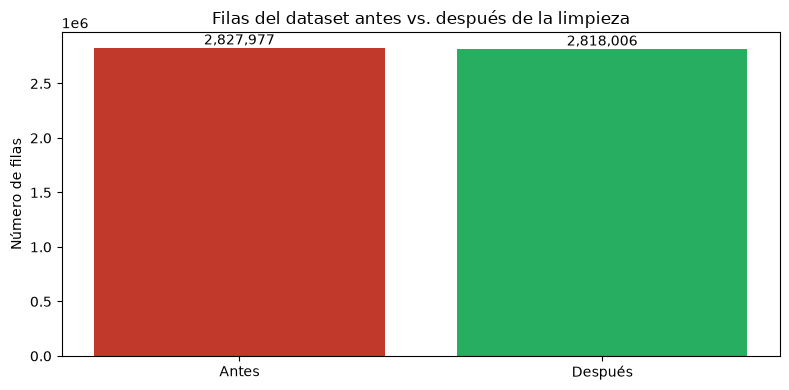

In [19]:
fig, ax = plt.subplots()
ax.bar(["Antes", "Después"], [filas_inicial, len(df)], color=["#c0392b", "#27ae60"])
ax.set_ylabel("Número de filas")
ax.set_title("Filas del dataset antes vs. después de la limpieza")
for i, v in enumerate([filas_inicial, len(df)]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [20]:
df.to_csv(OUTPUT_PATH, index=False)
print(f"Dataset limpio guardado en: {OUTPUT_PATH}")
print(f"Filas finales: {len(df):,} | Columnas finales: {df.shape[1]}")

Dataset limpio guardado en: water_quality_clean.csv
Filas finales: 2,818,006 | Columnas finales: 14


In [21]:
df.head(50)

,Country,Area,Waterbody_Type,Date,Ammonia_mgl,Biochemical_Oxygen_Demand_mgl,Dissolved_Oxygen_mgl,Orthophosphate_mgl,pH_ph_units,Temperature_cel,Nitrogen_mgl,Nitrate_mgl,CCME_Values,CCME_WQI
0,Canada,SE649035-145565,River,1974-01-12,0.059248,1.30000,8.150000,0.011917,8.07500,9.88500,0.343917,11.731550,100.000000,Excellent
1,Canada,SE649035-145565,River,1975-01-12,0.039821,1.38000,7.800000,0.009417,7.73333,10.15000,0.449083,11.820090,100.000000,Excellent
2,Canada,SE649035-145565,River,1976-01-12,0.031341,2.23000,7.800000,0.011000,7.46667,10.23500,0.220750,14.874720,100.000000,Excellent
3,Canada,SE649035-145565,River,1977-01-12,0.020501,1.61000,8.150000,0.012333,7.78333,11.11600,0.572250,15.892930,100.000000,Excellent
4,Canada,SE649035-145565,River,1978-01-12,0.020023,1.64000,4.370800,0.006182,7.10000,7.06800,0.371091,15.228880,100.000000,Excellent
5,Canada,SE649035-145565,River,1979-01-12,0.038211,1.46000,9.824000,0.007917,8.03333,9.81500,0.274167,15.937200,100.000000,Excellent
6,Canada,SE649035-145565,River,1980-01-12,0.074489,1.61000,10.716700,0.013000,7.79000,7.91600,0.226917,22.489160,100.000000,Excellent
7,Canada,SE649035-145565,River,1981-01-12,0.041645,1.36000,11.684103,0.016917,7.72000,11.03540,0.382667,13.723700,100.000000,Excellent
8,Canada,SE649035-145565,River,1982-01-12,0.052701,2.36000,9.200000,0.013500,7.90000,11.26860,0.312583,15.981470,100.000000,Excellent
9,Canada,SE649035-145565,River,1983-01-12,0.039460,3.30000,11.684103,0.008000,7.86000,9.62823,0.305727,17.663730,100.000000,Excellent
